# Atividade de Python para Ciência de Dados

Trainee: Sylvio Helt

## Entregável 1

In [1]:
import pandas as pd
import numpy as np

### A. Criação de Arrays

In [2]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")

In [3]:
preco_unitario = df["preco_unitario"].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto_pct = df["desconto_pct"].to_numpy()
receita_total = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()

In [4]:
print("Preço Unitário:", preco_unitario)
print("Custo Unitário:", custo_unitario)
print("Quantidade:", quantidade)
print("Desconto:", desconto_pct)
print("Receita Total:", receita_total)
print("Frete:", frete)

Preço Unitário: [ 739.39  187.48   76.11 ...   55.15  197.09 1057.41]
Custo Unitário: [561.75 135.15  61.4  ...  36.94 167.23 870.69]
Quantidade: [10  5 14 ...  7  7  4]
Desconto: [ 5.2  0.6  0.7 ...  0.  10.9 10. ]
Receita Total: [6933.48  930.28 1058.5  ...  384.44 1960.18 3795.73]
Frete: [ 8.68   nan  7.98 ... 85.35 30.99 27.23]


### B. Cálculos com operações vetorizadas

In [5]:
valor_bruto = df["preco_unitario"] * df["quantidade"]
valor_desconto = valor_bruto * (df["desconto_pct"] / 100)
custo_total = df["custo_unitario"] * df["quantidade"]
lucro_estimado = valor_bruto - valor_desconto - custo_total

print(valor_bruto)
print(valor_desconto)
print(custo_total)
print(lucro_estimado)

0        7393.90
1         937.40
2        1065.54
3        1604.46
4         133.92
          ...   
37612     657.99
37613     919.44
37614     386.05
37615    1379.63
37616    4229.64
Length: 37617, dtype: float64
0        384.48280
1          5.62440
2          7.45878
3          9.62676
4         26.11440
           ...    
37612    133.57197
37613     98.38008
37614      0.00000
37615    150.37967
37616    422.96400
Length: 37617, dtype: float64
0        5617.50
1         675.75
2         859.60
3         973.83
4         107.25
          ...   
37612     426.42
37613     666.00
37614     258.58
37615    1170.61
37616    3482.76
Length: 37617, dtype: float64
0        1391.91720
1         256.02560
2         198.48122
3         621.00324
4           0.55560
            ...    
37612      97.99803
37613     155.05992
37614     127.47000
37615      58.64033
37616     323.91600
Length: 37617, dtype: float64


### C. Máscaras Booleanas

In [7]:
# Criação das máscaras

receita_acima_media = df["receita_total"] > df["receita_total"].mean()

prejuizo = lucro_estimado < 0

desconto_alto = df["desconto_pct"] > df["desconto_pct"].mean()

In [8]:
# Contagem de casos das máscaras

print("Receita acima da média: ", receita_acima_media.sum(), "/ 37617")
print("Prejuízo: ", prejuizo.sum(), "/ 37617")
print("Desconto Alto: ", desconto_alto.sum(), "/ 37617")

Receita acima da média:  9236 / 37617
Prejuízo:  2857 / 37617
Desconto Alto:  17853 / 37617


In [9]:
df[receita_acima_media].head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,...,12,0.7,2167.48,6.80,4.52,14.0,False,False,True,False
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,7,5.9,7945.96,47.18,3.52,12.0,False,False,False,True
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,6,24.7,3314.59,48.72,2.94,4.0,False,True,False,False
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,14,5.9,11246.38,68.85,4.47,13.0,False,True,True,False


In [10]:
df[prejuizo].head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
8,2022-05-02,5,São Paulo,Site Web,Alimentação,Whey Protein,Bruno Souza,Prata,31.18,26.55,...,9,20.2,224.94,17.42,4.46,6.0,False,True,False,False
19,2022-11-05,11,Goiânia,Loja Física,Vestuário,Bermuda,Bruno Souza,Bronze,109.59,87.97,...,8,20.6,876.11,13.06,4.50,13.0,False,False,True,False
24,2022-07-11,7,Recife,App Mobile,Vestuário,Jaqueta,Ana Lima,Bronze,186.43,151.02,...,14,25.4,1954.39,15.96,5.00,2.0,False,True,False,False
55,2022-12-12,12,Porto Alegre,App Mobile,Esportes,Raquete,Elisa Costa,Bronze,70.12,57.12,...,14,19.5,1000.75,NaN,4.49,NaN,False,True,True,False
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,7,25.4,518.23,12.31,5.00,4.0,True,True,False,False


In [19]:
df[desconto_alto].head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
4,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
6,2022-01-21,1,manaus,Site Web,Livros,Python para Dados,Henrique Dias,Bronze,124.28,83.82,...,6,24.0,728.61,38.10,1.99,3.0,False,True,True,False
7,2023-09-07,9,manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,6,14.5,181.35,24.98,3.03,18.0,True,False,False,False
8,2022-05-02,5,são paulo,Site Web,Alimentação,Whey Protein,Bruno Souza,Prata,31.18,26.55,...,9,20.2,224.94,17.42,4.46,6.0,False,True,False,False
9,2023-04-12,4,rio de janeiro,App Mobile,Vestuário,Bermuda,Ana Lima,Bronze,191.19,114.64,...,2,24.6,287.32,29.63,4.01,19.0,False,True,False,False


### D. Agregações, Limpeza e Conclusão

In [20]:
receita_media = df["receita_total"].mean()
maior_receita = df["receita_total"].max()
menor_receita = df["receita_total"].min()

lucro_medio = lucro_estimado.mean()

qtd_prejuizo = (lucro_estimado < 0).sum()

print("Receita média:", receita_media)
print("Receita máxima:", maior_receita)
print("Receita mínima:", menor_receita)
print("Lucro médio:", lucro_medio)
print("Quantidade de vendas com prejuízo:", qtd_prejuizo)

Receita média: 1891.6881729005502
Receita máxima: 58430.28
Receita mínima: 3.7
Lucro médio: 342.0324771624531
Quantidade de vendas com prejuízo: 2857


Vamos também investigar como é o comportamento das vendas de acordo com a cidade na qual ocorreram.

Primeiro, vamos visualizar as cidades presentes no dataset de acordo com sua contagem. 

Podemos ver que as cidades estão bem representadas, com contagens parecidas em cada uma.

No entento, é possível ver também que os dados duplicatas, como "B. Horizonte" e "Belo horizonte" ou ainda incorreções, como "Slavador".

In [21]:
contagem_cidade = df["cidade"].value_counts()
print(contagem_cidade)

cidade
fortaleza         3853
curitiba          3822
manaus            3804
recife            3796
goiânia           3785
porto alegre      3722
rio de janeiro    3700
salvador          3699
são paulo         3666
belo horizonte    3664
curtiba             20
slavador            18
bh                  12
sp                  11
rio                 11
s. paulo            10
rj                   9
b. horizonte         9
sao paulo            6
Name: count, dtype: int64


Vamos fazer a limpeza desses valores:

In [22]:
mapa_cidades = {
    "slavador": "salvador",
    
    "curtiba": "curitiba",
    
    "s. paulo": "são paulo",
    "sp": "são paulo",
    "sao paulo": "são paulo",
    
    "rio": "rio de janeiro",
    "rj": "rio de janeiro",
    
    "bh": "belo horizonte",
    "b. horizonte": "belo horizonte",

    "goiania": "goiânia",
    
}

In [23]:
df["cidade"] = df["cidade"].replace(mapa_cidades)
df["cidade"] = df["cidade"].str.strip().str.lower()

In [24]:
print(df["cidade"].value_counts())

cidade
fortaleza         3853
curitiba          3842
manaus            3804
recife            3796
goiânia           3785
porto alegre      3722
rio de janeiro    3720
salvador          3717
são paulo         3693
belo horizonte    3685
Name: count, dtype: int64


Podemos investigar em quais cidades o percentual de vendas com prejuízo é maior:

In [27]:
lucro_estimado = valor_bruto - valor_desconto - custo_total

percent_prejuizo_por_cidade = df.groupby("cidade").apply(
    lambda x: np.mean(
        (x["preco_unitario"] * x["quantidade"]) -
        ((x["preco_unitario"] * x["quantidade"]) * (x["desconto_pct"] / 100)) -
        (x["custo_unitario"] * x["quantidade"]) < 0
    ) * 100
)

print(percent_prejuizo_por_cidade.sort_values(ascending=False))

cidade
goiânia           8.243065
curitiba          8.120770
manaus            7.991588
porto alegre      7.925846
belo horizonte    7.598372
recife            7.560590
fortaleza         7.474695
salvador          7.452246
são paulo         6.877877
rio de janeiro    6.666667
dtype: float64


Agora, vamos investigar quais cidades possuem o maior lucro médio por venda:

In [30]:
lucro_por_cidade = lucro_estimado.groupby(df["cidade"]).mean()
lucro_por_cidade = lucro_por_cidade.sort_values(ascending=False)

print(lucro_por_cidade)

cidade
recife            374.488654
porto alegre      347.245235
manaus            346.859312
belo horizonte    343.170396
fortaleza         342.933515
goiânia           341.861746
rio de janeiro    341.666306
salvador          330.793583
são paulo         328.968064
curitiba          322.094547
dtype: float64


Por fim, vamos investigar quais cidades possuem melhor percentual de entregas no prazo:

In [31]:
percentual_prazo = df.groupby("cidade")["entrega_no_prazo"].mean() * 100
percentual_prazo = percentual_prazo.sort_values(ascending=False)
print(percentual_prazo)

cidade
são paulo         78.608178
fortaleza         77.887360
belo horizonte    77.666214
rio de janeiro    77.419355
curitiba          77.355544
porto alegre      77.350887
goiânia           77.252312
recife            77.133825
manaus            77.076761
salvador          76.674738
Name: entrega_no_prazo, dtype: float64


Em nossa análise, descobrimos que ocorreram 2857 vendas com prejuízo e um lucro médio de 342,03 por venda. Ao tentar identificar cidades com maiores lucros, percentuais de vendas com prejuízos e entregas fora do prazo, perecebeu-se que há pouca diferença entre as cidades. No entanto, cabe notar que Recife foi a cidade cujas vendas possuíram o maior lucro médio e Goiânia a com mais vendas com prejuízo em termos relativos.

## Entregável 2

### Primeiro olhar no dataset

In [32]:
df.head()


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [33]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [34]:
df.describe()


,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [35]:
df.shape


(37617, 21)

In [36]:
df.isna().sum()


data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

1. 37617 linhas e 21 colunas

2. Sim, nas colunas avaliacao_cliente, frete, prazo_entrega_dias, margem_pct, vendedor, canal_venda. Isso pode ser observado na soma do isna().

3. mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias, valor_bruto, valor_desconto, custo_total, lucro_estimado.

4. Vários valores possíveis: data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente.
Binárias: devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco.

### B. Limpeza e tratamento

In [37]:
df["data_venda"] = pd.to_datetime(df["data_venda"], dayfirst=True, format="mixed")

Como já padronizamos cidade no item anterior, vamos agora padronizar canal de venda:

In [38]:
df["canal_venda"].value_counts()

canal_venda
Site Web       11267
App Mobile     11168
Loja Física     7445
Marketplace     5604
Televendas      1861
app mobile        33
SiteWeb           31
APP Mobile        29
App mobile        28
site web          24
Site web          24
loja física       22
Loja Fisica       18
Loja fisica       13
Name: count, dtype: int64

In [39]:
mapa_canal = {
    "loja fisica": "loja física",
    "siteweb": "site web"
}

df["canal_venda"] = df["canal_venda"].replace(mapa_canal)
df["canal_venda"] = df["canal_venda"].str.strip().str.lower()


In [40]:
df["canal_venda"].value_counts()

canal_venda
site web       11315
app mobile     11258
loja física     7467
marketplace     5604
televendas      1861
siteweb           31
loja fisica       31
Name: count, dtype: int64

In [41]:
df["frete"] = df["frete"].fillna(df["frete"].median())
df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna(df["avaliacao_cliente"].median())
df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(df["prazo_entrega_dias"].median())
df["margem_pct"] = df["margem_pct"].fillna(df["margem_pct"].median())
df["canal_venda"] = df["canal_venda"].fillna("Desconhecido")
df["vendedor"] = df["vendedor"].fillna("Desconhecido")

Foi usada a mediana para reduzir a influência de outliers. Desconhecido permite a idenficação, nas categorias categóricas, das vendas que não possuíam aquele valor.

In [42]:
df.isna().sum()


data_venda            0
mes                   0
cidade                0
canal_venda           0
categoria             0
produto               0
vendedor              0
fidelidade_cliente    0
preco_unitario        0
custo_unitario        0
margem_pct            0
quantidade            0
desconto_pct          0
receita_total         0
frete                 0
avaliacao_cliente     0
prazo_entrega_dias    0
devolucao             0
entrega_no_prazo      0
alta_temporada        0
flag_outlier_preco    0
dtype: int64

### C. Criação de novas colunas


In [48]:
df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce", dayfirst=True)

df["ano_venda"] = df["data_venda"].dt.year
df["mes_venda"] = df["data_venda"].dt.month

df["lucro_total"] = lucro_estimado

df["receita_liquida"] = df["receita_total"] - valor_desconto

df["faixa_receita"] = df["receita_total"].apply(
    lambda x: "Alta" if x > 2000 else "Média" if x > 500 else "Baixa"
)

print(df[["ano_venda", "mes_venda", "lucro_total", "receita_liquida", "faixa_receita"]].head())

   ano_venda  mes_venda  lucro_total  receita_liquida faixa_receita
0       2022          4   1391.91720       6548.99720          Alta
1       2023         12    256.02560        924.65560         Média
2       2022          9    198.48122       1051.04122         Média
3       2022          4    621.00324       1582.80324         Média
4       2022          3      0.55560         81.52560         Baixa


### D. Filtros

Vendas com altíssima receita (acima de 5000):

In [49]:
filtro_receita = df[df["receita_total"] > 5000]
print(filtro_receita.head())

   data_venda  mes          cidade  canal_venda    categoria     produto  \
0  2022-04-13    4  rio de janeiro   app mobile  Eletrônicos    Notebook   
15 2022-10-04    4        salvador  marketplace  Eletrônicos  Smartphone   
20 2022-10-12   12          recife     site web  Eletrônicos  Smartphone   
21 2023-07-05    5       são paulo  loja física  Eletrônicos  Smartwatch   
25 2022-04-10   10  rio de janeiro  loja física  Eletrônicos  Smartwatch   

       vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
0   Bruno Souza           Diamante          739.39          561.75  ...   
15     Ana Lima             Bronze         1213.88          843.05  ...   
20   Inês Nunes              Prata          603.40          394.18  ...   
21   Gabi Alves             Bronze          892.83          660.58  ...   
25  Bruno Souza           Diamante          449.00          293.50  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
0                  5.

Percebemos que essas vendas de alto valor são focadas em eletrônicos:

In [50]:
filtro_receita["categoria"].value_counts()

categoria
Eletrônicos    3888
Esportes        108
Livros            4
Vestuário         4
Name: count, dtype: int64

Vendas com devolução:

In [51]:
filtro_devolucao = df[df["devolucao"] == True]
print(filtro_devolucao.head())

   data_venda  mes     cidade  canal_venda    categoria       produto  \
1  2023-12-03    3     manaus     site web    Vestuário      Camiseta   
2  2022-09-28    9    goiânia   app mobile    Vestuário         Tênis   
7  2023-07-09    9     manaus   app mobile  Alimentação  Mel Orgânico   
18 2023-10-24   10     manaus     site web    Vestuário      Camiseta   
21 2023-07-05    5  são paulo  loja física  Eletrônicos    Smartwatch   

        vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
1    Elisa Costa             Bronze          187.48          135.15  ...   
2    João Vieira             Bronze           76.11           61.40  ...   
7     Inês Nunes              Prata           35.72           21.62  ...   
18  Carla Mendes              Prata           65.73           41.26  ...   
21    Gabi Alves             Bronze          892.83          660.58  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
1                 19.0       True

Avaliamos que o percentual de devoluções por canal foi semelhante:

In [52]:
total_por_canal = df.groupby("canal_venda").size()
devolucoes_por_canal = df[df["devolucao"] == True].groupby("canal_venda").size()

percentual_devolucao = (devolucoes_por_canal / total_por_canal) * 100

print(percentual_devolucao.sort_values(ascending=False))

canal_venda
app mobile      9.522118
site web        9.465312
marketplace     9.386153
televendas      9.349812
loja física     9.160305
siteweb         6.451613
Desconhecido    4.000000
loja fisica     3.225806
dtype: float64


Categoria específica:

In [53]:
filtro_categoria = df[df["categoria"] == "Vestuário"]
print(filtro_categoria.head())

   data_venda  mes          cidade  canal_venda  categoria      produto  \
1  2023-12-03    3          manaus     site web  Vestuário     Camiseta   
2  2022-09-28    9         goiânia   app mobile  Vestuário        Tênis   
3  2022-04-17    4       fortaleza     site web  Vestuário  Calça Jeans   
9  2023-12-04    4  rio de janeiro   app mobile  Vestuário      Bermuda   
10 2022-03-08    8    porto alegre  marketplace  Vestuário      Jaqueta   

         vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
1     Elisa Costa             Bronze          187.48          135.15  ...   
2     João Vieira             Bronze           76.11           61.40  ...   
3    Carla Mendes             Bronze          145.86           88.53  ...   
9        Ana Lima             Bronze          191.19          114.64  ...   
10  Henrique Dias             Bronze          131.40          104.65  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
1              

### E. Agroupamentos com Groupby

In [54]:
receita_categoria = df.groupby("categoria")["receita_total"].sum()
print(receita_categoria.sort_values(ascending=False))

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64


In [55]:
vendas_canal = df.groupby("canal_venda").size()
print(vendas_canal.sort_values(ascending=False))

canal_venda
site web        11315
app mobile      11258
loja física      7467
marketplace      5604
televendas       1861
Desconhecido       50
loja fisica        31
siteweb            31
dtype: int64


In [56]:
receita_cidade = df.groupby("cidade")["receita_total"].sum()
print(receita_cidade.sort_values(ascending=False))

cidade
recife            7662241.79
manaus            7459161.23
fortaleza         7242081.82
goiânia           7178113.69
porto alegre      7048428.17
curitiba          6993175.07
salvador          6918656.01
belo horizonte    6914747.61
rio de janeiro    6880176.34
são paulo         6862852.27
Name: receita_total, dtype: float64


In [59]:
valor_bruto = df["preco_unitario"] * df["quantidade"]
valor_desconto = valor_bruto * (df["desconto_pct"] / 100)
custo_total = df["custo_unitario"] * df["quantidade"]

lucro_estimado = valor_bruto - valor_desconto - custo_total

lucro_categoria = lucro_estimado.groupby(df["categoria"]).sum()

print(lucro_categoria.sort_values(ascending=False))

categoria
Eletrônicos    8.141113e+06
Esportes       2.082461e+06
Vestuário      1.232406e+06
Livros         8.126898e+05
Alimentação    5.975651e+05
dtype: float64


### F. Merge

In [60]:
df_regiao = pd.DataFrame({
    "cidade": [
        "são paulo",
        "rio de janeiro",
        "belo horizonte",
        "curitiba",
        "porto alegre",
        "salvador",
        "recife",
        "fortaleza",
        "goiânia",
        "manaus"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Sul",
        "Sul",
        "Nordeste",
        "Nordeste",
        "Nordeste",
        "Centro-Oeste",
        "Norte"
    ]
})

In [61]:
df_merged = df.merge(df_regiao, on="cidade", how="left")

Receita total por região:

In [62]:
receita_regiao = df_merged.groupby("regiao")["receita_total"].sum()
print(receita_regiao.sort_values(ascending=False))

regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64


Total de vendas por região:

In [63]:
vendas_regiao = df_merged.groupby("regiao").size()
print(vendas_regiao.sort_values(ascending=False))

regiao
Nordeste        11366
Sudeste         11098
Sul              7564
Norte            3804
Centro-Oeste     3785
dtype: int64


Observamos que as vendas mais caras são de eletrônicos, que há mais vendas nas regiões Sudeste e Nordeste, que site web e app mobile são os canais mais populares e que Recife é a cidade com maior receita.

## Entregável 3

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

### A. Gráfico de barras

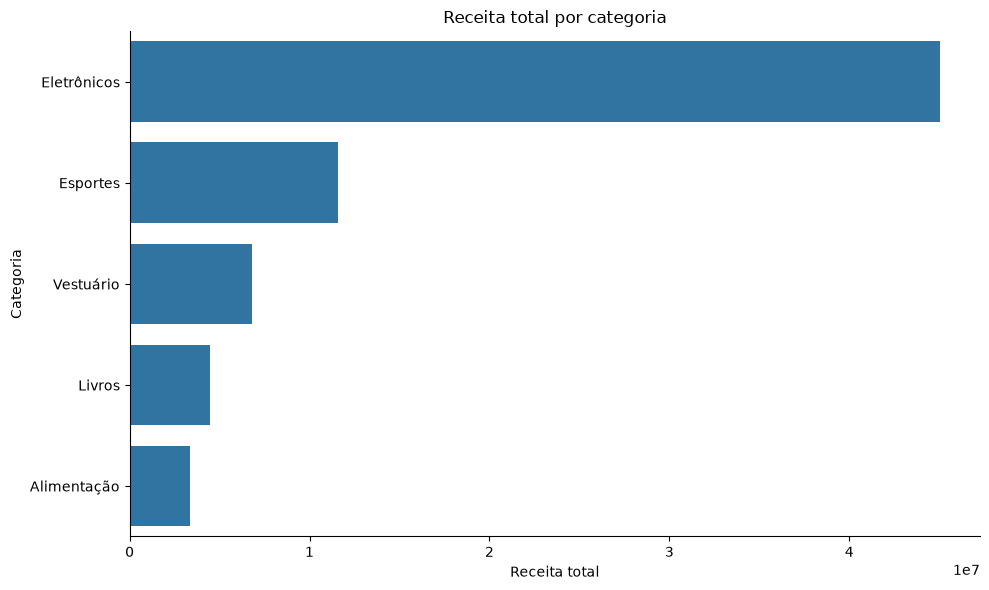

In [65]:
plt.figure(figsize=(10,6))

cat = (
    df.groupby("categoria")["receita_total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=cat, x="receita_total", y="categoria", linewidth=1)

plt.title("Receita total por categoria")
plt.xlabel("Receita total")
plt.ylabel("Categoria")

sns.despine()
plt.tight_layout()
plt.show()

O gráfico mostra a receita em cada categoria, revelando que eletrônicos possuem a maior receita total.

## B. Gráfico de Linhas

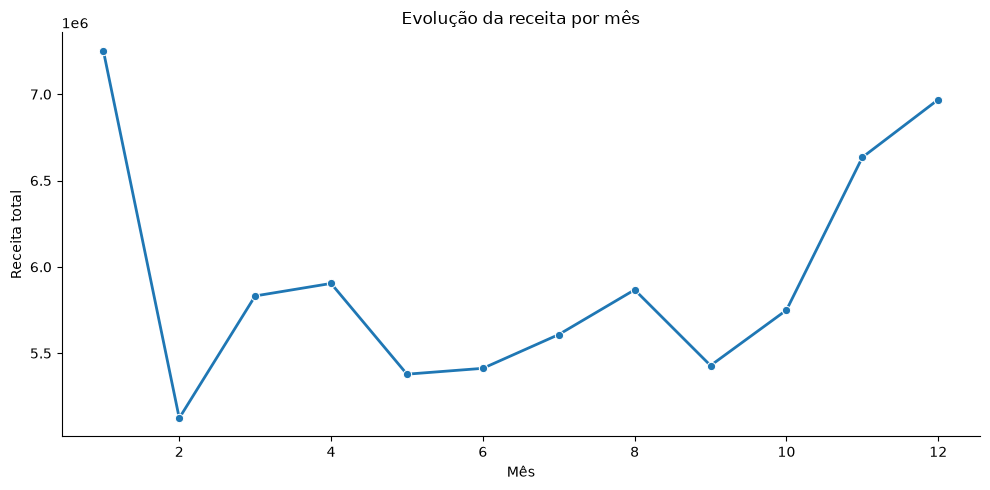

In [66]:
plt.figure(figsize=(10,5))

mes = df.groupby("mes_venda")["receita_total"].sum().reset_index()

sns.lineplot(data=mes, x="mes_venda", y="receita_total", marker="o", linewidth=2)

plt.title("Evolução da receita por mês")
plt.xlabel("Mês")
plt.ylabel("Receita total")

sns.despine()
plt.tight_layout()
plt.show()

Esse gráfico exibe a variação da receita ao longo dos meses, que permite perceber que no final e início do ano as vendas são maiores.

### 

### C. Gráfico de Dispersão

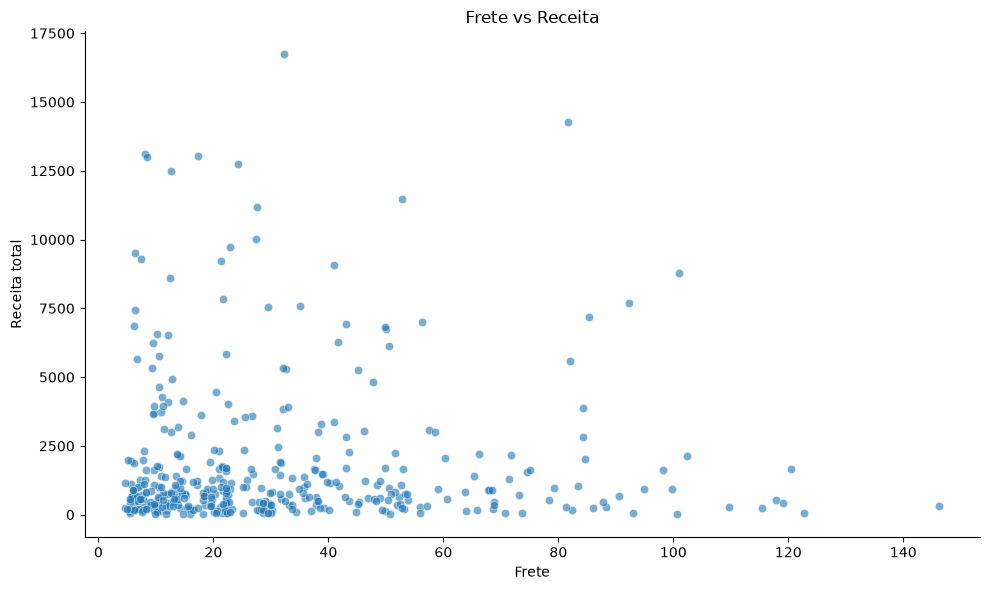

In [67]:
plt.figure(figsize=(10,6))

amostra = df.sample(400, random_state=42)

sns.scatterplot(
    data=amostra,
    x="frete",
    y="receita_total",
    alpha=0.6
)

plt.title("Frete vs Receita")
plt.xlabel("Frete")
plt.ylabel("Receita total")

sns.despine()
plt.tight_layout()
plt.show()

Não se percebe relação linear clara entre frete e receita no gráfico. Como há valores eleveados no eixo y, vamos tentar uma escala logarítimica.

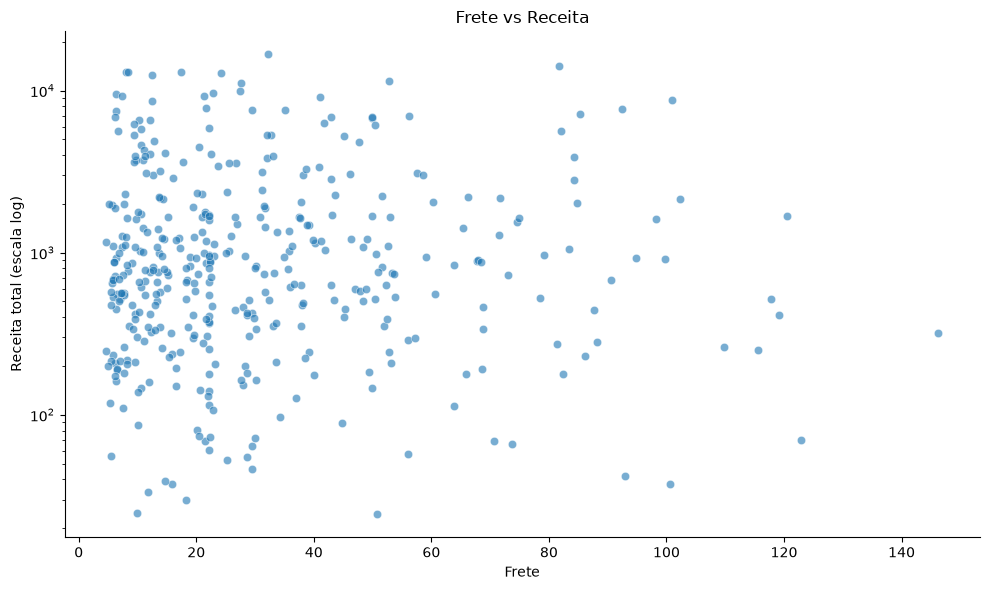

In [68]:
plt.figure(figsize=(10,6))

amostra = df.sample(400, random_state=42)

sns.scatterplot(
    data=amostra,
    x="frete",
    y="receita_total",
    alpha=0.6
)

plt.yscale("log")

plt.title("Frete vs Receita")
plt.xlabel("Frete")
plt.ylabel("Receita total (escala log)")

sns.despine()
plt.tight_layout()
plt.show()

Novamente, não é possível estabelecer uma relação clara entre frete e receita.

### D. Heatmap de correlação

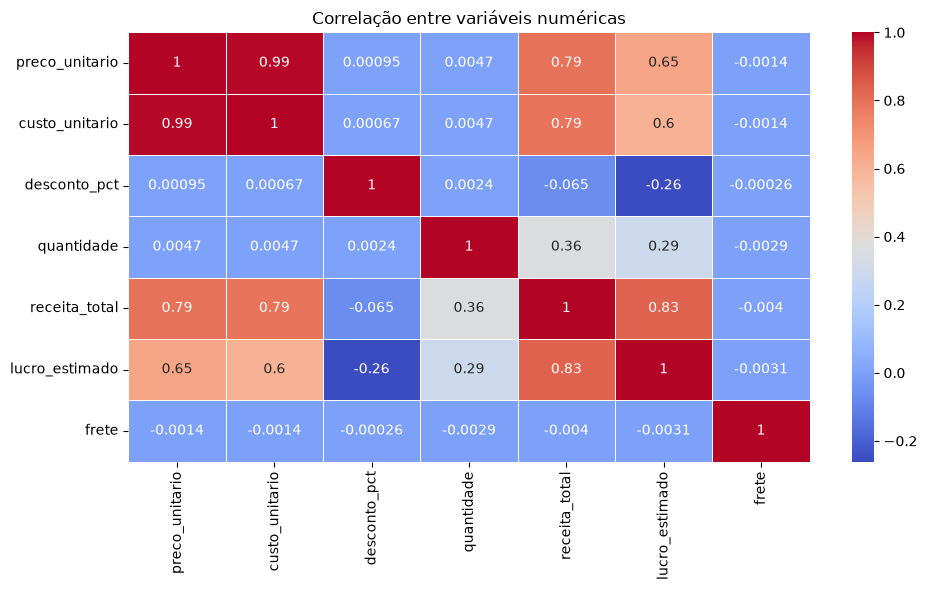

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

valor_bruto = df["preco_unitario"] * df["quantidade"]
valor_desconto = valor_bruto * (df["desconto_pct"] / 100)
custo_total = df["custo_unitario"] * df["quantidade"]

lucro_estimado = valor_bruto - valor_desconto - custo_total

df_corr = df.copy()
df_corr["lucro_estimado"] = lucro_estimado

cols = [
    "preco_unitario",
    "custo_unitario",
    "desconto_pct",
    "quantidade",
    "receita_total",
    "lucro_estimado",
    "frete"
]

corr = df_corr[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

Preço unitário: Apresenta forte correlação positiva com custo_unitario (0,99), receita_total (0,79) e lucro_estimado (0,65).

Custo unitário: Possui forte correlação positiva com preço_unitario (0,99), receita_total (0,79) e lucro_estimado (0,60).

Desconto percentual: Apresenta correlação negativa moderada com lucro_estimado (-0,26), indicando redução da lucratividade com maiores descontos.

Quantidade: Possui correlação positiva com receita_total (0,36) e lucro_estimado (0,29).

Receita total: Está fortemente correlacionada com preço_unitario (0,79), custo_unitario (0,79) e lucro_estimado (0,83), além de apresentar correlação moderada com quantidade (0,36).

Lucro estimado: Apresenta forte correlação positiva com receita_total (0,83), preço_unitario (0,65) e custo_unitario (0,60), e correlação negativa moderada com desconto_pct (-0,26).

Frete: Não apresentou correlações relevantes com as demais variáveis.